In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [5]:
x = df.drop('Survived', axis = 1)
y = df['Survived']

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [7]:
x_train.head()

,Age,Fare,Family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [8]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [9]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [10]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [11]:
x_train.sample(10)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
256,NaN,79.2000,0,28.0,29.498846,79.2000,79.2000
153,40.5,14.5000,2,40.5,40.500000,14.5000,14.5000
794,25.0,7.8958,0,25.0,25.000000,7.8958,7.8958
274,NaN,7.7500,0,28.0,29.498846,7.7500,7.7500
252,62.0,26.5500,0,62.0,62.000000,26.5500,26.5500
301,NaN,23.2500,2,28.0,29.498846,23.2500,23.2500
405,34.0,21.0000,1,34.0,34.000000,21.0000,21.0000
715,19.0,7.6500,0,19.0,19.000000,7.6500,7.6500
887,19.0,30.0000,0,19.0,19.000000,30.0000,30.0000
570,62.0,10.5000,0,62.0,62.000000,10.5000,10.5000


In [12]:
#check for the variance of the new features
print(x_train['Age_median'].var())
print(x_train['Age_mean'].var())
print(df['Age'].var())

169.20731007048096
168.8519336687225
211.0191247463081


In [13]:

#check for the variance of the new features
print(x_train['Fare_median'].var())
print(x_train['Fare_mean'].var())
print(df['Fare'].var())

2637.01248167777
2621.2323749512393
2530.6730768999487


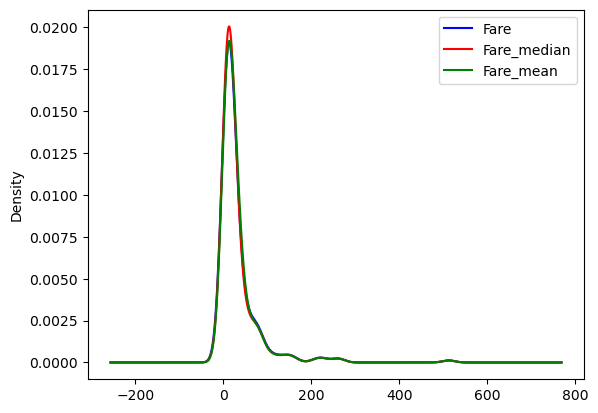

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Fare'].plot(kind = 'kde', ax = ax, color = 'blue')
x_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')
x_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [15]:
# this is a green flag

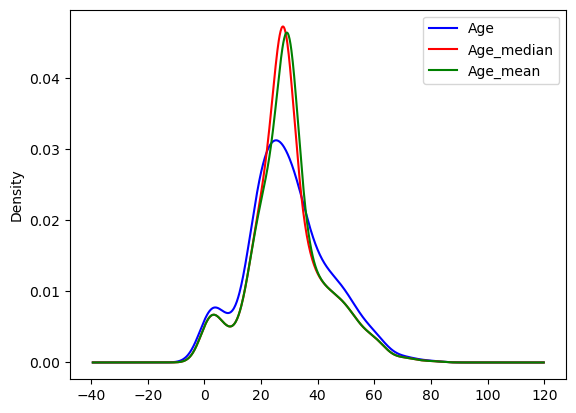

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind = 'kde', ax = ax, color = 'blue')
x_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'red')
x_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [17]:
# drastic changes in age column it is a red flag

In [18]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


<Axes: >

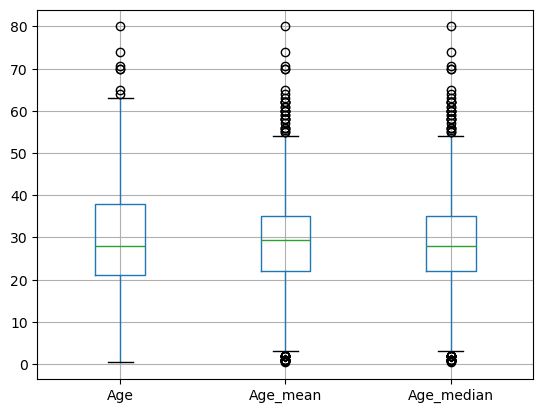

In [19]:
x_train[["Age","Age_mean","Age_median"]].boxplot()

In [20]:
# iqr shrinks so that the variance of the new features is less than the original feature. This is a green flag.

<Axes: >

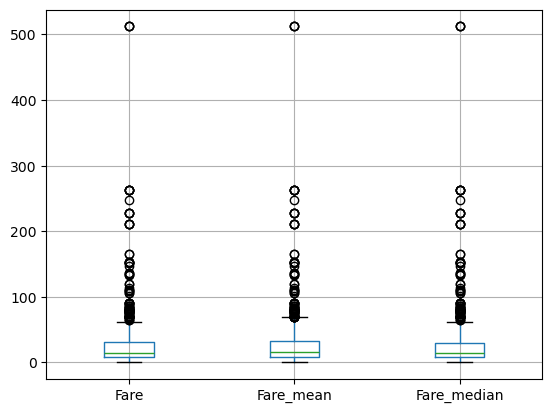

In [21]:
x_train[["Fare","Fare_mean","Fare_median"]].boxplot()

In [22]:
# Using Sklean's SimpleImputer

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [23]:
imputer1 = SimpleImputer(strategy = 'mean')
imputer2 = SimpleImputer(strategy = 'median')

In [24]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
],remainder = 'passthrough')

In [26]:
trf.fit(x_train)

C:\Users\parth\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1624: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(), ['Age']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [27]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [29]:
x_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])